# Data loadings and preparations

> data loading and preparation utilities start here to understand the data journey.

In [1]:
#| default_exp data.__init__

In [2]:
#| hide
from nbdev.showdoc import *

In [9]:
#| export
import importlib
from dataclasses import dataclass
from typing import Dict
from omegaconf import OmegaConf, DictConfig
from dataclasses import is_dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributed as dist

from fastcore.utils import *
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import *
from flwr_datasets.preprocessor import Merger

from fedai.data.vision import VisionBlock
from fedai.core import get_clean_kwargs

In [10]:
#| export
def get_preprocessor(cfg):
    dataset_dict = {"train": "train", "test": "test"}
    if cfg.data.name == "tinyimagenet":
        dataset_dict = {"train": "train", "valid": "valid"}
        
    merger = Merger(
        merge_config={
             "train": tuple(list(key for key in dataset_dict.keys())),
            }
        )
    return merger

In [11]:
#| export
def init_data(cfg):
    if cfg.partitioner.cls in ["GroupedDistributionPartitioner", "GroupedClassPartitioner", "VariableClassPartitioner", "RotatedPatchedPartitioner"]:
        module = importlib.import_module("fedai.data.vision.partitioners")
        
    else: 
        module = importlib.import_module("flwr_datasets.partitioner")
    
    partitioner_cls = getattr(module, cfg.partitioner.cls)
    kwargs = get_clean_kwargs(cfg.partitioner)
    kwargs.pop("cls", None)
    
    partitioner = partitioner_cls(**kwargs, seed= cfg.random_seed)    
    preprocessor = get_preprocessor(cfg)
    
    fds = FederatedDataset(dataset= cfg.data.hf_name, 
                           partitioners= {"train": partitioner},
                           preprocessor= preprocessor,
                           seed= 42)
    
    return fds

In [12]:
#| hide
from fedai.cfgs.data import MNISTRotatedPatchedConfig, CIFAR10Config, TinyImageNetConfig
from fedai.cfgs.partitioners import RotatedBatchedConfig, PathologicalConfig, GroupedDistributionPartitionerConfig
from omegaconf import OmegaConf
import numpy as np


In [15]:
#| hide
cfg = OmegaConf.create({})
cfg.data = TinyImageNetConfig()
cfg.partitioner = PathologicalConfig()
cfg.random_seed = 42    
fds = init_data(cfg)


In [16]:
#| hide
partition = fds.load_partition(partition_id= 16, split= "train")
partition

/home/ahmed/miniconda3/envs/fed/lib/python3.12/site-packages/flwr_datasets/partitioner/pathological_partitioner.py:188: UserWarning: Classes: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 37, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 88, 91, 92, 93, 94, 95, 96, 97, 98, 100, 101, 103, 104, 106, 107, 108, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 126, 127, 129, 130, 131, 132, 133, 135, 136, 137, 138, 140, 141, 142, 143, 144, 145, 147, 149, 150, 151, 153, 157, 158, 159, 160, 161, 162, 164, 166, 168, 169, 171, 172, 173, 174, 175, 176, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 194, 195, 196, 197, 198, 199] will NOT be used due to the chosen configuration. If it is undesired behavior consider setting 'first_class_deterministic_assignme

Dataset({
    features: ['image', 'label'],
    num_rows: 825
})

In [17]:
#| hide
np.unique(partition["label"])

array([134, 155])

In [14]:
#| export
def get_block(cfg, client_id, fds= None, train=True):

    if cfg.data.modality.lower() == "vision":
        return VisionBlock(cfg.data, client_id, train= train, fds= fds, seed= 42)

In [15]:
#| hide
block = get_block(cfg, client_id= 1, fds= fds, train=True)

In [16]:
#| hide
type(block[0]['image'])

torch.Tensor

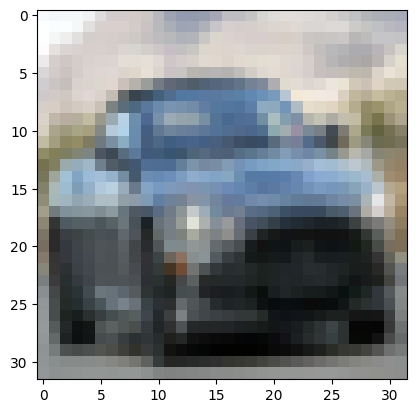

(tensor([0.0823, 0.1922, 0.0084]), tensor([0.8280, 0.7462, 0.8041]))

In [18]:
#| hide
import matplotlib.pyplot as plt
import numpy as np

def show_normalized_img(img_tensor, mean, std):
    # img_tensor shape: (C, H, W)
    img = img_tensor.clone().numpy().transpose(1, 2, 0)
    
    # Reverse the normalization: (x * std) + mean
    img = img * np.array(std) + np.array(mean)
    
    # Clip to [0, 1] just in case of rounding errors
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.show()

# Usage with your block:
show_normalized_img(block[0]['image'], cfg.data.mean, cfg.data.std)
idx = np.random.randint(0, len(block))
block[idx]['image'].mean(dim=(1, 2)), block[idx]['image'].std(dim=(1, 2))

In [ ]:
#| hide
imgs = torch.stack([block[i]['image'] for i in range(len(block))], dim=0)  # (N, C, H, W)

print(imgs.mean(dim=[0, 2, 3]))  # should be close to [0, 0, 0]
print(imgs.std(dim=[0, 2, 3], unbiased=False))   # should be close to [1, 1, 1]

tensor([-0.0592, -0.0386, -0.0575])
tensor([1.2339, 1.2350, 1.2956])


In [ ]:
#| hide
image, label = block[2]["image"], block[2]["label"]
print(image.shape, image.min(), image.max())
plt.imshow(image.permute(1, 2, 0), cmap= "gray" if image.shape[0] == 1 else None)
print(label)
plt.show()

In [19]:
#| export
def prepare_dl_dist(
        cfg,
        client_id,
        fds,
        train= True,
        collator=torch.utils.data.default_collate,
):
    block = get_block(cfg= cfg, client_id= client_id, fds= fds, train= train)

    dist_sampler = torch.utils.data.distributed.DistributedSampler(block)

    data_loader = torch.utils.data.DataLoader(
        block,
        collate_fn=collator,
        sampler=dist_sampler,
        batch_size=cfg.data.get("batch_size", 32),
        drop_last=cfg.data.get("drop_last", False),
        pin_memory=cfg.data.get("pin_memory", False),
        num_workers=cfg.data.get("num_workers", 0),
        persistent_workers=(cfg.data.get("num_workers", 0) > 0) and cfg.data.get("persistent_workers", False),
    )


    return data_loader, dist_sampler

In [20]:
#| export
def prepare_dl(cfg, client_id, fds, train=True, distributed=False):
    if distributed and torch.distributed.is_initialized():
        return prepare_dl_dist(cfg, client_id, fds, train)
    
    block = get_block(cfg, client_id, fds, train)
    dl = torch.utils.data.DataLoader(block, batch_size= cfg.data.batch_size, shuffle= True if train else False) # TODO: make sure you put batch_size to dataConfig keys
    return dl

In [21]:
#| hide
dl = prepare_dl(cfg, client_id=15, fds= fds, train=True)
batch = next(iter(dl))
print(batch["image"].shape, batch["label"].shape)

torch.Size([128, 3, 32, 32]) torch.Size([128])


In [22]:
#| hide
dist.init_process_group(backend="gloo", init_method="tcp://localhost:12345", rank=0, world_size=1)
dist_dl, dist_sampler = prepare_dl(cfg, client_id=15, fds= fds, train=True, distributed=True)
dist.destroy_process_group()


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


In [23]:
#| hide
dist_sampler.set_epoch(0)
batch= next(iter(dist_dl))
print(batch["image"].shape, batch["label"].shape)

torch.Size([128, 3, 32, 32]) torch.Size([128])


In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()